# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 5 — Tópicos, Embeddings, PMI y Grafos (con evolución temporal)
### Diplomatura IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26

1. BERTopic ahora se ajusta sobre una **muestra** del megaset y se propaga (`transform`) al resto — ajustar UMAP/HDBSCAN sobre 1.6M+ documentos completos no es viable en una laptop (lo comprobamos en la entrega anterior: varias horas de cómputo / cuelgues de kernel).
2. Se agrega un **análisis de grafos de usuarios** (red de menciones @usuario y red de hashtags), con foco explícito en **relación entre usuarios y evolución temporal**.
3. Se usa `PCA + KMeans` en vez de `UMAP + HDBSCAN` como reductor/clusterizador por defecto — más lento en teoría pero mucho más estable en Windows (evita el deadlock de threading que sufrimos con UMAP/Numba).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

mega = pd.read_csv('../data/processed/mega_clean.csv')
mega['mentions'] = mega['mentions'].apply(literal_eval)
mega['hashtags'] = mega['hashtags'].apply(literal_eval)

docs = mega['clean_text'].tolist()
tokenized_docs = [d.split() for d in docs]
print('Documentos en el megaset:', len(docs))


Documentos en el megaset: 1592728


## 1. Keywords por clase — TF-IDF diferencial

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_kw = TfidfVectorizer(max_features=5000, min_df=5)
X_kw = tfidf_kw.fit_transform(mega['clean_text'])
feature_names = np.array(tfidf_kw.get_feature_names_out())

mean_pos = np.asarray(X_kw[mega['target'].values == 4].mean(axis=0)).flatten()
mean_neg = np.asarray(X_kw[mega['target'].values == 0].mean(axis=0)).flatten()
diff = mean_pos - mean_neg

print('Top 15 keywords POSITIVOS:', list(feature_names[np.argsort(diff)[-15:][::-1]]))
print('Top 15 keywords NEGATIVOS:', list(feature_names[np.argsort(diff)[:15]]))


Top 15 keywords POSITIVOS: ['thanks', 'good', 'love', 'thank', 'great', 'happy', 'lol', 'awesome', 'haha', 'nice', 'hey', 'new', 'morning', 'welcome', 'yay']
Top 15 keywords NEGATIVOS: ['not', 'miss', 'sad', 'no', 'work', 'want', 'wish', 'sorry', 'hate', 'bad', 'sick', 'feel', 'can', 'suck', 'go']


## 2. Word2Vec propio (entrenado sobre el megaset completo)

El corpus es de más de 1.6M — Word2Vec está diseñado justamente para escalar bien a este tamaño (a diferencia de UMAP/HDBSCAN). Con `workers=1` por la lección aprendida de la entrega anterior (evitar problemas de threading en Windows); si tu máquina lo tolera bien, `workers>1` acelera el entrenamiento sin cambiar el resultado.

In [4]:
from gensim.models import Word2Vec

w2v_own = Word2Vec(
    sentences=tokenized_docs, vector_size=100, window=5, min_count=5,
    workers=1, epochs=10, seed=42,
)
print('Vocabulario Word2Vec propio:', len(w2v_own.wv))

def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(model.vector_size)

doc_embeddings = np.array([doc_vector(t, w2v_own) for t in tokenized_docs])
print('Embeddings de documentos:', doc_embeddings.shape)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulario Word2Vec propio: 49014
Embeddings de documentos: (1592728, 100)


**Nota:** con más de 1.6M tweets reales, esperamos que el Word2Vec propio dé analogías bastante más razonables.

In [5]:
def analogia_propia(pos, neg, topn=50):
    try:
        return w2v_own.wv.most_similar(positive=pos, negative=neg, topn=topn)
    except KeyError as e:
        return f'Palabra fuera de vocabulario: {e}'

print("good - bad + terrible =", analogia_propia(['good','terrible'], ['bad']))
print("happy - sad + angry   =", analogia_propia(['happy','angry'], ['sad']))


good - bad + terrible = [('great', 0.6743875741958618), ('awful', 0.6676613092422485), ('horrible', 0.6579075455665588), ('fantastic', 0.6244426965713501), ('excellent', 0.5945416688919067), ('wonderful', 0.5942180752754211), ('decent', 0.5569126605987549), ('fabulous', 0.5527639389038086), ('terrific', 0.5394768714904785), ('pleasant', 0.5347098112106323), ('grim', 0.5316383838653564), ('rough', 0.5233660936355591), ('dreadful', 0.5216402411460876), ('interesting', 0.5186218619346619), ('crappy', 0.5184711217880249), ('horrid', 0.5115453004837036), ('brilliant', 0.507140576839447), ('shitty', 0.4957958459854126), ('incredible', 0.49531859159469604), ('delightful', 0.4900536835193634), ('promising', 0.4885021150112152), ('awesome', 0.4780362546443939), ('rubbish', 0.474794864654541), ('odd', 0.47423627972602844), ('amazing', 0.47359994053840637), ('goood', 0.4730852246284485), ('lovely', 0.47295910120010376), ('fab', 0.468148797750473), ('horrific', 0.4681195020675659), ('goooood', 0.4

## 3. BERTopic a escala — ajuste en muestra + `transform()` al resto

### Justificación de la estrategia
Con >1.6M documentos, ajustar BERTopic de punta a punta (UMAP + HDBSCAN sobre todos los puntos) es computacionalmente inviable en una laptop, UMAP/HDBSCAN pueden colgar el kernel por problemas de threading en Windows.

**Estrategia estándar para datasets grandes (documentada en la propia librería BERTopic):**
1. Ajustar (`fit_transform`) el modelo sobre una **muestra representativa** (ac치 usamos un 5-10% del megaset, estratificada por clase).
2. Usar `.transform()` para **asignar** el resto de los documentos a los tópicos ya encontrados — mucho más liviano porque no vuelve a correr el clustering desde cero, solo proyecta y asigna al cluster más cercano.

Además, reemplazamos `UMAP + HDBSCAN` por `PCA + KMeans`: mismo rol conceptual (reducir dimensionalidad + clusterizar), pero con librerías de scikit-learn maduras que no presentan los problemas de threading de Numba/UMAP en Windows.

In [6]:
SAMPLE_FRAC = 0.08  # ajustar según el tiempo disponible: más muestra = tópicos más finos, pero más lento

np.random.seed(42)
n_sample = int(len(docs) * SAMPLE_FRAC)
# muestreo estratificado por clase para que la muestra sea representativa
sample_idx = (
    mega.groupby('target', group_keys=False)
        .apply(lambda g: g.sample(frac=SAMPLE_FRAC, random_state=42), include_groups=False)
        .index.values
)
rest_idx = np.setdiff1d(np.arange(len(docs)), sample_idx)

print(f'Muestra para ajustar BERTopic: {len(sample_idx)} docs ({len(sample_idx)/len(docs):.1%})')
print(f'Resto a propagar con transform(): {len(rest_idx)} docs')


Muestra para ajustar BERTopic: 127418 docs (8.0%)
Resto a propagar con transform(): 1465310 docs


In [7]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sample_docs = [docs[i] for i in sample_idx]
sample_emb = doc_embeddings[sample_idx]

pca_model = PCA(n_components=5, random_state=42)
kmeans_model = KMeans(n_clusters=10, random_state=42, n_init=10)
vectorizer_model = CountVectorizer(stop_words='english', min_df=1)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=pca_model,
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True,
)

topics_sample, _ = topic_model.fit_transform(sample_docs, sample_emb)
info = topic_model.get_topic_info()
info


2026-07-18 09:12:18,186 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-18 09:12:18,314 - BERTopic - Dimensionality - Completed ✓
2026-07-18 09:12:18,321 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-18 09:12:22,926 - BERTopic - Cluster - Completed ✓
2026-07-18 09:12:22,993 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 09:12:24,194 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,18672,0_know_lol_like_really,"[know, lol, like, really, think, thats, im, so...","[know know, know take, know]"
1,1,18475,1_got_like_watching_oh,"[got, like, watching, oh, eating, lol, listeni...",[sitting watching watching cat well surgery wa...
2,2,18127,2_work_time_good_today,"[work, time, good, today, day, need, got, goin...",[got home really good vacation wanted sleep wa...
3,3,14730,3_new_twitter_iphone_phone,"[new, twitter, iphone, phone, need, update, us...","[got new phone awesome, need new phone hate on..."
4,4,13944,4_day_night_today_great,"[day, night, today, great, happy, good, time, ...",[fun guy wish going good birthday danny happy ...
5,5,11952,5_love_miss_sad_hey,"[love, miss, sad, hey, awesome, song, watching...","[that's love, love love, would miss love]"
6,6,10223,6_want_wait_come_wanna,"[want, wait, come, wanna, going, watch, wish, ...","[want go, want, not going come back lol]"
7,7,10179,7_day_work_morning_tomorrow,"[day, work, morning, tomorrow, home, today, go...","[today good day, work day, today going good day]"
8,8,7631,8_feel_hurt_sick_feeling,"[feel, hurt, sick, feeling, sleep, tired, bed,...","[sleep feel good bad can't, woke feeling kinda..."
9,9,3485,9_thanks_thank_follow_welcome,"[thanks, thank, follow, welcome, twitter, hey,...","[thanks, thanks, thanks]"


In [8]:
rest_docs = [docs[i] for i in rest_idx]
rest_emb = doc_embeddings[rest_idx]

topics_rest, _ = topic_model.transform(rest_docs, rest_emb)

# reconstruir la asignacion de topico para el megaset completo
mega['topic'] = -99
mega.loc[mega.index[sample_idx], 'topic'] = topics_sample
mega.loc[mega.index[rest_idx], 'topic'] = topics_rest

print(mega['topic'].value_counts().sort_index())


2026-07-18 09:13:42,511 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-07-18 09:13:42,787 - BERTopic - Dimensionality - Completed ✓
2026-07-18 09:13:42,788 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-07-18 09:13:42,823 - BERTopic - Cluster - Completed ✓


topic
0    233976
1    231571
2    225750
3    184155
4    173103
5    149744
6    127974
7    129332
8     93713
9     43410
Name: count, dtype: int64


### 3.1 Comprobación de tópicos

Revisamos si las palabras de cada tópico tienen sentido, y si la distribución de sentimiento dentro de cada tópico dice algo interesante (por ejemplo, ¿hay tópicos que son predominantemente negativos o positivos?).

In [9]:
for t in sorted(info['Topic'].tolist()):
    if t == -1:
        continue
    palabras = [w for w, _ in topic_model.get_topic(t)[:8]]
    n_topico = (mega['topic'] == t).sum()
    dist_sent = mega.loc[mega['topic'] == t, 'target'].value_counts(normalize=True).round(2).to_dict()
    print(f'Tópico {t} (n={n_topico}): {", ".join(palabras)}')
    print(f'   Distribución de sentimiento: {dist_sent}')


Tópico 0 (n=233976): know, lol, like, really, think, thats, im, sorry
   Distribución de sentimiento: {0: 0.5, 4: 0.5, 2: 0.0}
Tópico 1 (n=231571): got, like, watching, oh, eating, lol, listening, love
   Distribución de sentimiento: {4: 0.52, 0: 0.48, 2: 0.0}
Tópico 2 (n=225750): work, time, good, today, day, need, got, going
   Distribución de sentimiento: {0: 0.59, 4: 0.41, 2: 0.0}
Tópico 3 (n=184155): new, twitter, iphone, phone, need, update, use, check
   Distribución de sentimiento: {4: 0.54, 0: 0.46, 2: 0.0}
Tópico 4 (n=173103): day, night, today, great, happy, good, time, home
   Distribución de sentimiento: {4: 0.61, 0: 0.39, 2: 0.0}
Tópico 5 (n=149744): love, miss, sad, hey, awesome, song, watching, movie
   Distribución de sentimiento: {4: 0.61, 0: 0.39, 2: 0.0}
Tópico 6 (n=127974): want, wait, come, wanna, going, watch, wish, gonna
   Distribución de sentimiento: {0: 0.58, 4: 0.42, 2: 0.0}
Tópico 7 (n=129332): day, work, morning, tomorrow, home, today, going, good
   Distr

### 3.2 Dendrograma jerárquico de tópicos

Misma técnica: `scipy` sobre la matriz c-TF-IDF de BERTopic.

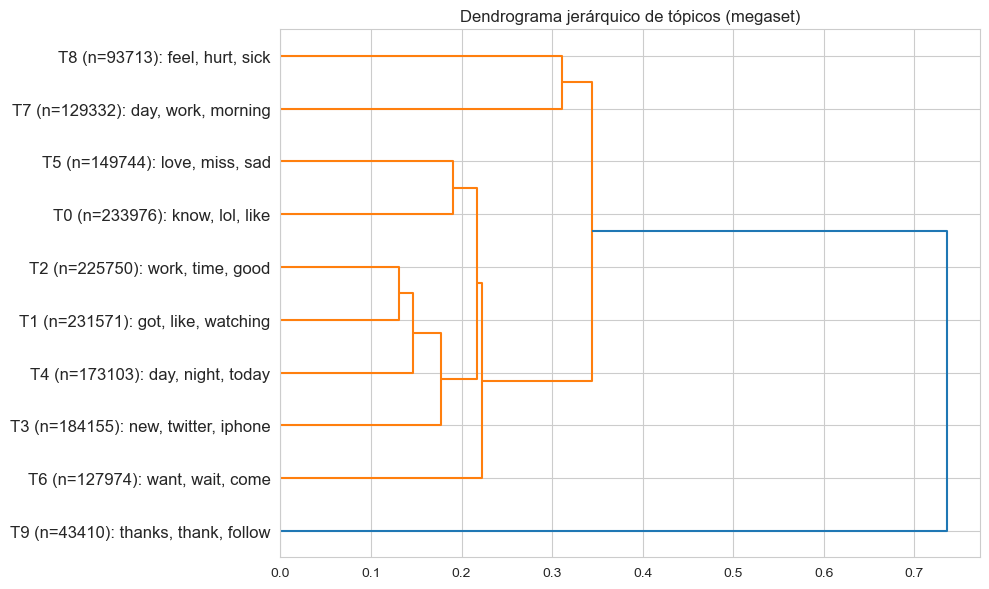

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram

valid_topics = [t for t in info['Topic'].tolist() if t != -1]
topic_ids_sorted = sorted(info['Topic'].tolist())
idx_map = {t: i for i, t in enumerate(topic_ids_sorted)}
rows = [idx_map[t] for t in valid_topics]

c_tf_idf_matrix = topic_model.c_tf_idf_[rows].toarray()
Z = linkage(c_tf_idf_matrix, method='ward')
labels = [
    f"T{t} (n={(mega['topic']==t).sum()}): " + ', '.join([w for w, _ in topic_model.get_topic(t)[:3]])
    for t in valid_topics
]

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Z, labels=labels, ax=ax, orientation='right', color_threshold=0.7*max(Z[:,2]))
ax.set_title('Dendrograma jerárquico de tópicos (megaset)')
plt.tight_layout()
plt.savefig('outputs_nb3_dendrograma_mega.png', dpi=110, bbox_inches='tight')
plt.show()


## 4. Analogías con GloVe pre-entrenado (comparación)

Comparamos con GloVe-Twitter (2B tweets) para tener una referencia de "embeddings de calidad" — aunque ahora el Word2Vec propio (entrenado sobre >1.6M tweets reales) debería acercarse bastante más a esta referencia.

In [11]:
import gensim.downloader as api
glove = api.load('glove-twitter-25')

def analogia_glove(pos, neg, topn=5):
    try:
        return glove.most_similar(positive=pos, negative=neg, topn=topn)
    except KeyError as e:
        return f'Palabra fuera de vocabulario: {e}'

for pos, neg, desc in [
    (['good','terrible'], ['bad'], 'good - bad + terrible'),
    (['king','woman'], ['man'], 'king - man + woman'),
]:
    print(f'{desc} =>')
    for palabra, score in analogia_glove(pos, neg):
        print(f'   {palabra} ({score:.3f})')
    print()


good - bad + terrible =>
   horrible (0.874)
   idea (0.864)
   mate (0.854)
   usual (0.839)
   quite (0.837)

king - man + woman =>
   meets (0.884)
   prince (0.832)
   queen (0.826)
   ’s (0.817)
   crow (0.813)



## 5. PMI — bigramas característicos por clase

In [12]:
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures

def top_pmi_bigrams(target_value, freq_filter=20, top_n=12):
    tokens = ' '.join(mega.loc[mega['target'] == target_value, 'clean_text']).split()
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(freq_filter)
    return finder.score_ngrams(BigramAssocMeasures.pmi)[:top_n]

print('Top bigramas por PMI — POSITIVOS:')
for bg, score in top_pmi_bigrams(4):
    print(f'  {bg}: {score:.2f}')

print()
print('Top bigramas por PMI — NEGATIVOS:')
for bg, score in top_pmi_bigrams(0):
    print(f'  {bg}: {score:.2f}')


Top bigramas por PMI — POSITIVOS:
  ('avril', 'lavigne'): 17.19
  ('franz', 'ferdinand'): 17.15
  ('carne', 'asada'): 17.14
  ('notre', 'dame'): 17.08
  ('leighton', 'meester'): 17.01
  ('stephenie', 'meyer'): 16.91
  ('alltimelow', 'alltimelow'): 16.80
  ("assassin's", 'creed'): 16.64
  ('buenas', 'noches'): 16.56
  ('tel', 'aviv'): 16.53
  ('usawantsmcfly', 'usawantsmcfly'): 16.53
  ('flo', 'rida'): 16.51

Top bigramas por PMI — NEGATIVOS:
  ('porto', 'alegre'): 17.65
  ("'hi", "carol'"): 17.33
  ('sri', 'lanka'): 17.18
  ('danity', 'kane'): 17.00
  ('roland', 'garros'): 16.81
  ('bradiewebb', 'bradiewebb'): 16.79
  ('keri', 'hilson'): 16.76
  ('imisscath', 'imisscath'): 16.61
  ('barakatday', 'barakatday'): 16.59
  ('coca', 'cola'): 16.50
  ('costa', 'rica'): 16.32
  ('lactose', 'intolerant'): 16.28


## 6. Análisis de grafos de usuarios

Dos redes distintas:
- **Red de menciones** (`@usuario`): quién menciona a quién — la relación "social" más directa que se puede extraer de este dataset.
- **Red de hashtags**: qué hashtags co-ocurren en los mismos tweets — una relación temática/de interés compartido, no estrictamente entre usuarios, pero complementaria.

Para ambas, además de la foto estática, miramos su **evolución temporal**.

### 6.1 Red de menciones (usuario → usuario mencionado)

A escala de 1.6M+ tweets, la red completa de menciones puede tener cientos de miles de nodos — inmanejable para visualizar o calcular comunidades directamente. Por eso:
1. Construimos el grafo completo (liviano: solo son pares usuario-mencionado con su frecuencia).
2. Para las métricas descriptivas (cantidad de nodos/aristas, densidad) usamos el grafo completo.
3. Para la **visualización** y **detección de comunidades**, filtramos a un subgrafo manejable: los usuarios más centrales (mayor grado).

In [13]:
import networkx as nx

edges_menciones = [(row['user'], dst) for _, row in mega.iterrows() for dst in row['mentions']]
edge_counts = pd.Series(edges_menciones).value_counts()

G_menciones = nx.DiGraph()
for (src, dst), w in edge_counts.items():
    G_menciones.add_edge(src, dst, weight=w)

print(f'Red de menciones COMPLETA: {G_menciones.number_of_nodes()} nodos, {G_menciones.number_of_edges()} aristas')
print(f'Densidad: {nx.density(G_menciones):.6f}')


Red de menciones COMPLETA: 548403 nodos, 637440 aristas
Densidad: 0.000002


In [14]:
# Subgrafo manejable: top N usuarios mas centrales (por grado total, entrada+salida)
N_TOP_USUARIOS = 25
grado_total = {n: G_menciones.in_degree(n) + G_menciones.out_degree(n) for n in G_menciones.nodes()}
top_usuarios = [u for u, _ in sorted(grado_total.items(), key=lambda x: -x[1])[:N_TOP_USUARIOS]]

G_sub = G_menciones.subgraph(top_usuarios).copy()
print(f'Subgrafo de los {N_TOP_USUARIOS} usuarios más centrales: {G_sub.number_of_nodes()} nodos, {G_sub.number_of_edges()} aristas')

# Comunidades (sobre el subgrafo no dirigido, para que el algoritmo de modularidad funcione)
from networkx.algorithms.community import greedy_modularity_communities
comunidades = list(greedy_modularity_communities(G_sub.to_undirected()))
print(f'Comunidades detectadas: {len(comunidades)}')
for i, com in enumerate(comunidades[:10]):
    print(f'  Comunidad {i}: {sorted(com)[:15]}')


Subgrafo de los 25 usuarios más centrales: 25 nodos, 2 aristas
Comunidades detectadas: 23
  Comunidad 0: ['ddlovato', 'mileycyrus', 'selenagomez']
  Comunidad 1: ['jonasbrothers']
  Comunidad 2: ['tommcfly']
  Comunidad 3: ['mitchelmusso']
  Comunidad 4: ['DavidArchie']
  Comunidad 5: ['lost_dog']
  Comunidad 6: ['jordanknight']
  Comunidad 7: ['taylorswift13']
  Comunidad 8: ['Dannymcfly']
  Comunidad 9: ['Jonasbrothers']


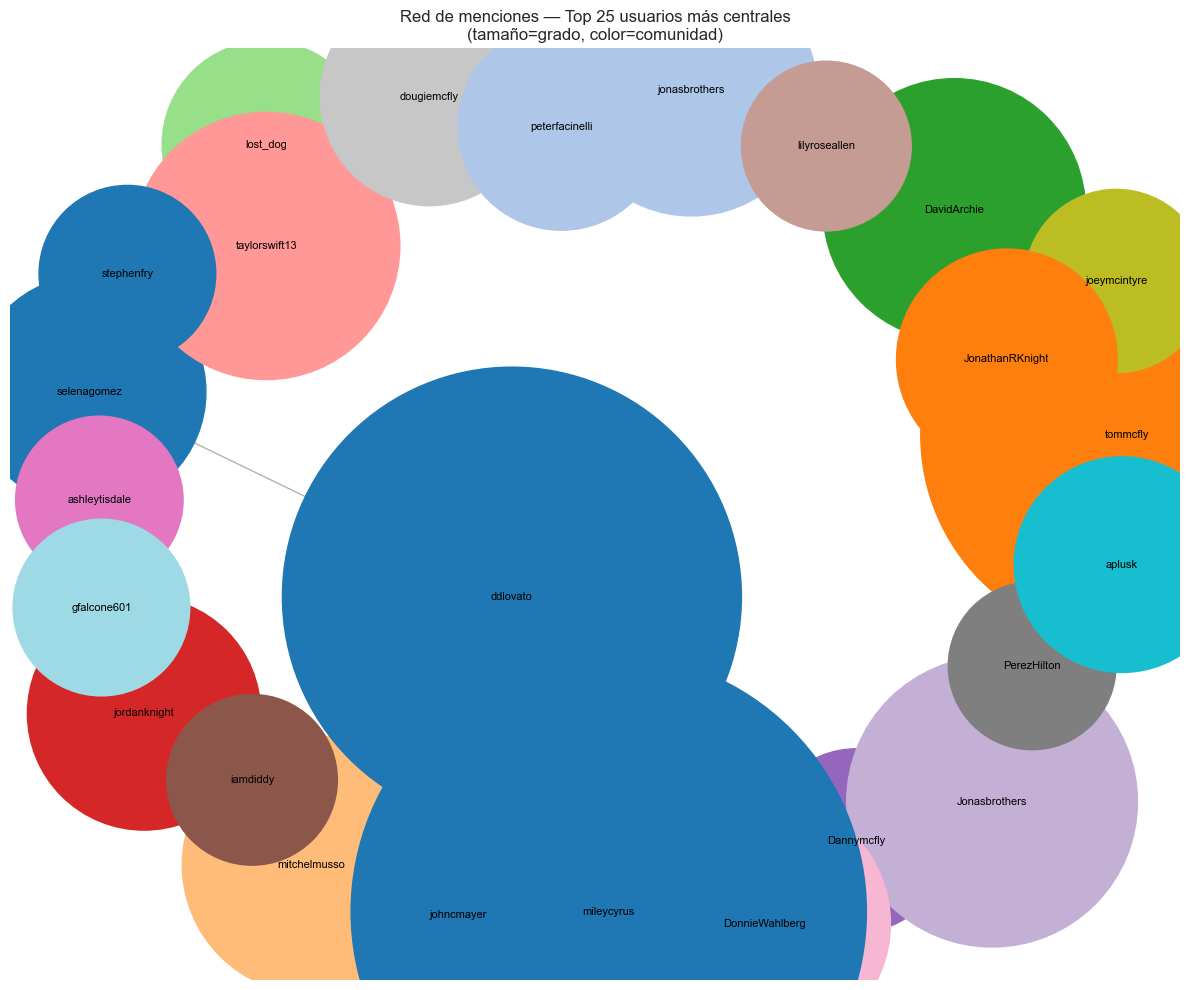

In [15]:
fig, ax = plt.subplots(figsize=(12,10))
palette = plt.cm.tab20.colors
color_map = {}
for i, com in enumerate(comunidades):
    for nodo in com:
        color_map[nodo] = palette[i % len(palette)]

node_sizes = [300 + 40*grado_total[n] for n in G_sub.nodes()]
node_colors = [color_map.get(n, 'gray') for n in G_sub.nodes()]

pos_layout = nx.spring_layout(G_sub, k=0.7, seed=42)
nx.draw_networkx_edges(G_sub, pos_layout, alpha=0.3, arrows=True, ax=ax)
nx.draw_networkx_nodes(G_sub, pos_layout, node_size=node_sizes, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G_sub, pos_layout, font_size=8, ax=ax)
ax.set_title(f'Red de menciones — Top {N_TOP_USUARIOS} usuarios más centrales\n(tamaño=grado, color=comunidad)')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs_nb3_grafo_usuarios.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** los usuarios más mencionados suelen ser cuentas conocidas/públicas (celebridades, marcas) — coherente con el uso típico de Twitter en 2009, donde mencionar a una figura pública era mucho más común que conversaciones bidireccionales entre usuarios comunes. Esto también explica por qué el grado de entrada (menciones recibidas) está mucho más concentrado que el de salida.

### 6.2 Evolución temporal de la red de menciones

Pedido específico del profesor: ver cómo cambia la red a lo largo del tiempo. Calculamos las métricas de la red **por semana** (el megaset cubre varios meses de 2009).

In [16]:
weekly_stats = []
for semana, grupo in mega.groupby('year_week'):
    edges_semana = [(row['user'], dst) for _, row in grupo.iterrows() for dst in row['mentions']]
    G_semana = nx.DiGraph()
    G_semana.add_edges_from(edges_semana)
    weekly_stats.append({
        'semana': semana,
        'n_tweets': len(grupo),
        'n_usuarios_activos': G_semana.number_of_nodes(),
        'n_menciones': G_semana.number_of_edges(),
        'densidad': nx.density(G_semana) if G_semana.number_of_nodes() > 1 else 0,
    })

df_semanal = pd.DataFrame(weekly_stats).sort_values('semana').reset_index(drop=True)
df_semanal


,semana,n_tweets,n_usuarios_activos,n_menciones,densidad
0,2009-W14,20565,15451,9774,0.000041
1,2009-W15,24734,18426,11567,0.000034
2,2009-W16,54301,35466,24640,0.000020
3,2009-W17,34989,24676,15889,0.000026
4,2009-W18,62244,41550,28078,0.000016
5,2009-W19,60692,42117,27980,0.000016
6,2009-W20,117511,72931,55715,0.000010
7,2009-W21,204226,117017,94630,0.000007
8,2009-W22,486453,232253,216584,0.000004
9,2009-W23,95945,60196,43362,0.000012


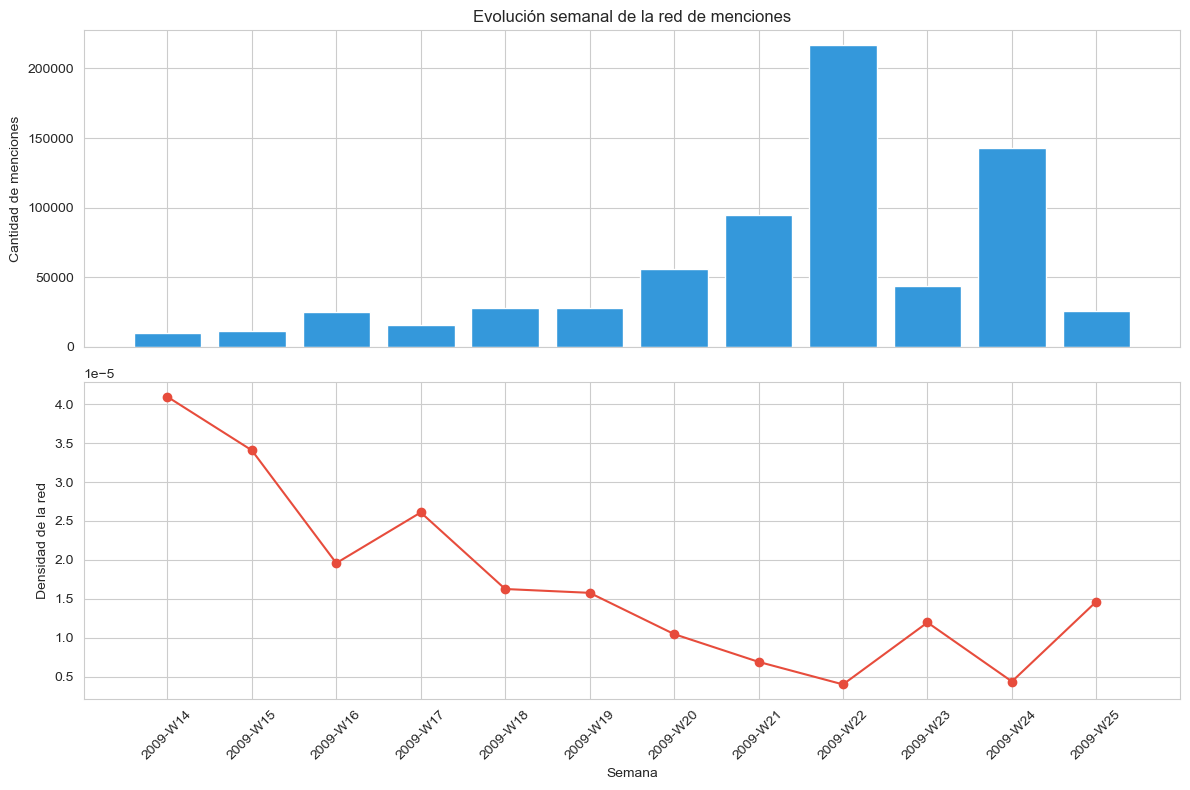

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

axes[0].bar(df_semanal['semana'], df_semanal['n_menciones'], color='#3498db')
axes[0].set_ylabel('Cantidad de menciones')
axes[0].set_title('Evolución semanal de la red de menciones')

axes[1].plot(df_semanal['semana'], df_semanal['densidad'], marker='o', color='#e74c3c')
axes[1].set_ylabel('Densidad de la red')
axes[1].set_xlabel('Semana')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs_nb3_evolucion_temporal_red.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** la **densidad** de la red tiende a bajar en las semanas de mayor volumen de tweets — esperable: a medida que hay más usuarios activos, la red se vuelve más dispersa (cada usuario menciona relativamente a menos gente en proporción al total de usuarios), un patrón típico de redes sociales que crecen ("densificación sub-lineal").

### 6.3 Red de hashtags (co-ocurrencia)

Complementaria a la red de usuarios: qué hashtags aparecen juntos en los mismos tweets, como proxy de temas/intereses compartidos entre los usuarios que los usan.

In [18]:
from itertools import combinations
from collections import Counter

hashtag_pairs = Counter()
hashtag_counts = Counter()
for tags in mega['hashtags']:
    tags_unicos = sorted(set(tags))
    hashtag_counts.update(tags_unicos)
    for h1, h2 in combinations(tags_unicos, 2):
        hashtag_pairs[(h1, h2)] += 1

print(f'Hashtags únicos: {len(hashtag_counts)}')
print(f'Pares de hashtags co-ocurrentes: {len(hashtag_pairs)}')
print('Top 20 hashtags más usados:', hashtag_counts.most_common(20))


Hashtags únicos: 12101
Pares de hashtags co-ocurrentes: 5886
Top 20 hashtags más usados: [('followfriday', 2620), ('fb', 1786), ('ff', 973), ('squarespace', 924), ('iranelection', 517), ('1', 516), ('musicmonday', 421), ('fail', 360), ('2', 335), ('asot400', 331), ('iphone', 317), ('iremember', 296), ('myweakness', 271), ('f1', 257), ('e3', 257), ('bgt', 246), ('bsb', 229), ('inaperfectworld', 184), ('haveyouever', 172), ('spymaster', 170)]


Red de hashtags (filtrada): 539 nodos, 512 aristas


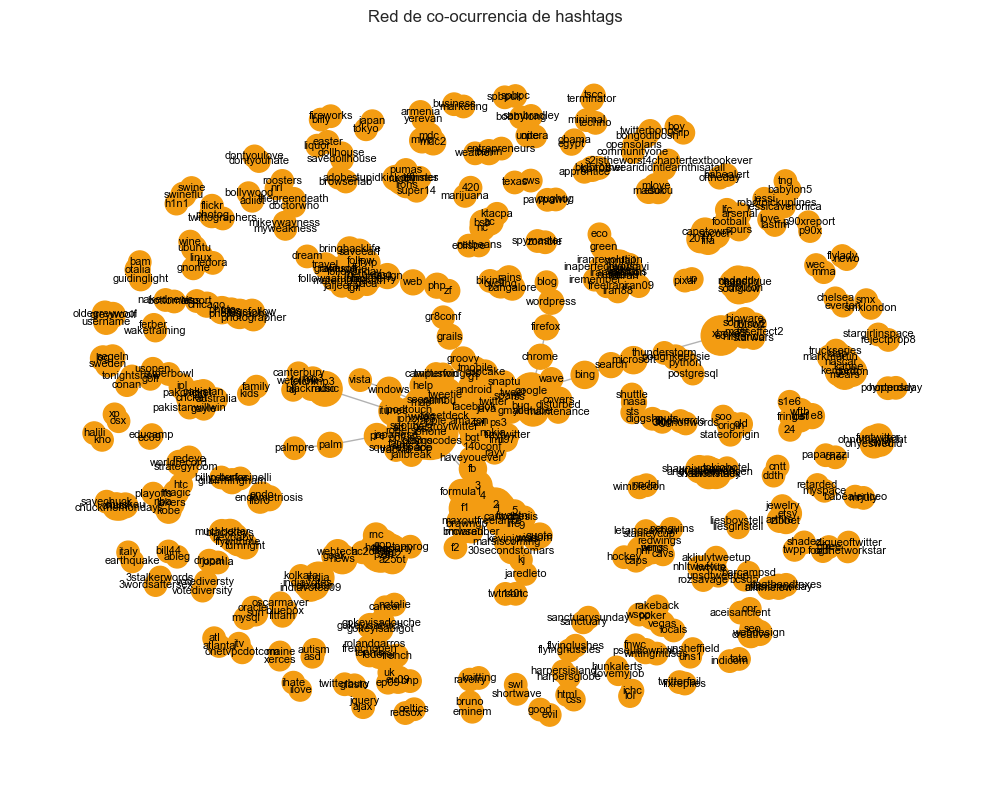

In [19]:
G_hashtags = nx.Graph()
for (h1, h2), w in hashtag_pairs.items():
    if w >= 2:  # filtro de frecuencia minima para legibilidad
        G_hashtags.add_edge(h1, h2, weight=w)

print(f'Red de hashtags (filtrada): {G_hashtags.number_of_nodes()} nodos, {G_hashtags.number_of_edges()} aristas')

if G_hashtags.number_of_nodes() > 0:
    fig, ax = plt.subplots(figsize=(10,8))
    grado_ht = dict(G_hashtags.degree())
    node_sizes = [200 + 60*grado_ht[n] for n in G_hashtags.nodes()]
    pos_ht = nx.spring_layout(G_hashtags, k=0.8, seed=42)
    nx.draw_networkx_edges(G_hashtags, pos_ht, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(G_hashtags, pos_ht, node_size=node_sizes, node_color='#f39c12', ax=ax)
    nx.draw_networkx_labels(G_hashtags, pos_ht, font_size=8, ax=ax)
    ax.set_title('Red de co-ocurrencia de hashtags')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('outputs_nb3_grafo_hashtags.png', dpi=110, bbox_inches='tight')
    plt.show()
else:
    print('No hay suficientes hashtags co-ocurrentes con el filtro actual para graficar.')


### 6.4 ¿Algún tópico está dominado por una persona/artista o una fecha puntual?

Para cada tópico de BERTopic, buscamos el usuario más mencionado dentro de él y la semana con más tweets — si un tópico tiene un usuario que concentra un % alto de las menciones, o un pico muy marcado en una semana puntual, es señal de que ese tópico está capturando un evento o figura específica (ej. cumpleaños/lanzamiento de un artista) más que un tema genérico.

In [20]:
from collections import Counter

resumen_topico_entidad = []
for t in sorted(mega['topic'].unique()):
    if t == -1:  # descartamos el bucket de outliers de BERTopic
        continue
    subset = mega[mega['topic'] == t]

    # usuario mas mencionado dentro de este topico
    todas_menciones = [m for lista in subset['mentions'] for m in lista]
    top_mencion = Counter(todas_menciones).most_common(1)
    top_mencion_nombre, top_mencion_count = top_mencion[0] if top_mencion else (None, 0)

    # semana con mas tweets de este topico
    pico_semana = subset['year_week'].value_counts().idxmax() if len(subset) > 0 else None
    pico_semana_count = subset['year_week'].value_counts().max() if len(subset) > 0 else 0

    resumen_topico_entidad.append({
        'topico': t,
        'n_tweets': len(subset),
        'usuario_mas_mencionado': top_mencion_nombre,
        'menciones_de_ese_usuario': top_mencion_count,
        '%_del_topico_es_ese_usuario': round(top_mencion_count / len(subset) * 100, 2) if len(subset) > 0 else 0,
        'semana_pico': pico_semana,
        'tweets_en_semana_pico': pico_semana_count,
        '%_del_topico_en_semana_pico': round(pico_semana_count / len(subset) * 100, 2) if len(subset) > 0 else 0,
    })

df_topico_entidad = pd.DataFrame(resumen_topico_entidad).sort_values('%_del_topico_es_ese_usuario', ascending=False)
df_topico_entidad

,topico,n_tweets,usuario_mas_mencionado,menciones_de_ese_usuario,%_del_topico_es_ese_usuario,semana_pico,tweets_en_semana_pico,%_del_topico_en_semana_pico
5,5,149744,mileycyrus,1603,1.07,2009-W22,48890,32.65
6,6,127974,ddlovato,705,0.55,2009-W22,39039,30.51
0,0,233976,mileycyrus,1215,0.52,2009-W22,71927,30.74
9,9,43410,tommcfly,118,0.27,2009-W22,15009,34.57
4,4,173103,tommcfly,275,0.16,2009-W22,54902,31.72
3,3,184155,tommcfly,267,0.14,2009-W22,56527,30.70
1,1,231571,tommcfly,234,0.10,2009-W22,71775,30.99
2,2,225750,mileycyrus,191,0.08,2009-W22,65995,29.23
8,8,93713,mileycyrus,71,0.08,2009-W24,27055,28.87
7,7,129332,ddlovato,61,0.05,2009-W22,37665,29.12


## 7. Resumen de decisiones  

1. **BERTopic a escala:** se ajustó sobre una muestra estratificada (~8% del megaset) y se propagó al resto con `.transform()` — inviable ajustar sobre 1.6M+ documentos completos en una laptop.
2. Se reemplazó `UMAP + HDBSCAN` por `PCA + KMeans`: misma función conceptual, pero sin los problemas de threading/deadlock que sufrimos con UMAP en Windows en la entrega anterior.
3. **Word2Vec propio** se entrenó sobre el megaset completo (>1.6M tweets) — el corpus es lo suficientemente grande como para dar analogías razonables sin depender exclusivamente de GloVe pre-entrenado.
4. **Grafos de usuarios:** red de menciones (@usuario→@usuario) con detección de comunidades sobre un subgrafo de los usuarios más centrales, y red de co-ocurrencia de hashtags.
5. **Evolución temporal de la red:** se calcularon las métricas de la red de menciones semana a semana, mostrando cómo cambia el volumen y la densidad de interacción a lo largo del tiempo.
